## Hands-on Examples on Applied Markov Models

We explore two use cases of (discrete-time) Markov chains on health economics and dynamic treatment design. 

1. **A discrete-time Markov health economic model**
   - disease progression with three states
   - cohort-state propagation and individual Monte Carlo microsimulation
   - expected **costs**, **QALYs**, and **ICER**

2. **A simple Q-learning for treatment policy design**
   - a toy treatment decision problem framed as a Markov decision process (MDP)
   - learning a treatment policy from simulated experience
   - comparing the learned policy to simple fixed policies


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## Part I. Markov health economic model

We use a very simple annual-cycle disease progression model with three states:

- **0 = Healthy**
- **1 = Diseased**
- **2 = Dead**

We compare two strategies:

- **Standard care**
- **New treatment**

Each strategy has its own transition probability matrix.  
Each living state also has a utility (for QALYs) and a cost per cycle.


In [2]:
state_names = ["Healthy", "Diseased", "Dead"]
n_states = len(state_names)

# Transition matrices: rows = current state, columns = next state
P_standard = np.array([
    [0.86, 0.11, 0.03],   # Healthy
    [0.00, 0.78, 0.22],   # Diseased
    [0.00, 0.00, 1.00],   # Dead
])

P_new = np.array([
    [0.90, 0.08, 0.02],   # Better protection from disease progression and death
    [0.00, 0.82, 0.18],
    [0.00, 0.00, 1.00],
])

# Annual state costs and utilities
state_costs = np.array([500, 6000, 0], dtype=float)
state_utils = np.array([0.95, 0.65, 0.0], dtype=float)

# Extra treatment acquisition cost per cycle for those alive
drug_cost_standard = 500.0
drug_cost_new = 2500.0

cycle_length = 1.0   # 1 year
n_cycles = 20 # 20 years in total 
discount_rate_cost = 0.03
discount_rate_qaly = 0.03

initial_dist = np.array([1.0, 0.0, 0.0])

def check_transition_matrix(P):
    assert np.all(P >= 0), "Transition matrix has negative entries."
    assert np.allclose(P.sum(axis=1), 1), "Rows must sum to 1."

check_transition_matrix(P_standard)
check_transition_matrix(P_new)


### Discounting

In cost-effectiveness analysis, future costs and QALYs are often discounted:

$$
w_t^{(c)} = \frac{1}{(1+r_c)^t}, \qquad
w_t^{(q)} = \frac{1}{(1+r_q)^t}.
$$

We will index cycles as $t=0,1,\dots,T-1$.


In [3]:
def discount_weights(n_cycles, rate):
    t = np.arange(n_cycles)
    return 1.0 / (1.0 + rate) ** t

w_cost = discount_weights(n_cycles, discount_rate_cost)
w_qaly = discount_weights(n_cycles, discount_rate_qaly)

pd.DataFrame({
    "cycle": np.arange(n_cycles),
    "cost_weight": w_cost,
    "qaly_weight": w_qaly,
}).head()


,cycle,cost_weight,qaly_weight
0,0,1.000000,1.000000
1,1,0.970874,0.970874
2,2,0.942596,0.942596
3,3,0.915142,0.915142
4,4,0.888487,0.888487


### Cohort Markov model

For a cohort model, the state distribution evolves as

$$
\pi_{t+1} = \pi_t P.
$$

This gives expected proportions in each health state over time.


In [5]:
def simulate_cohort(P, initial_dist, n_cycles):
    dist = np.zeros((n_cycles + 1, len(initial_dist)))
    dist[0] = initial_dist
    for t in range(n_cycles):
        dist[t + 1] = dist[t] @ P
    return dist

cohort_standard = simulate_cohort(P_standard, initial_dist, n_cycles)
cohort_new = simulate_cohort(P_new, initial_dist, n_cycles)

cohort_standard[:5] # check out first five years (cohort distributions)


array([[1.        , 0.        , 0.        ],
       [0.86      , 0.11      , 0.03      ],
       [0.7396    , 0.1804    , 0.08      ],
       [0.636056  , 0.222068  , 0.141876  ],
       [0.54700816, 0.2431792 , 0.20981264]])

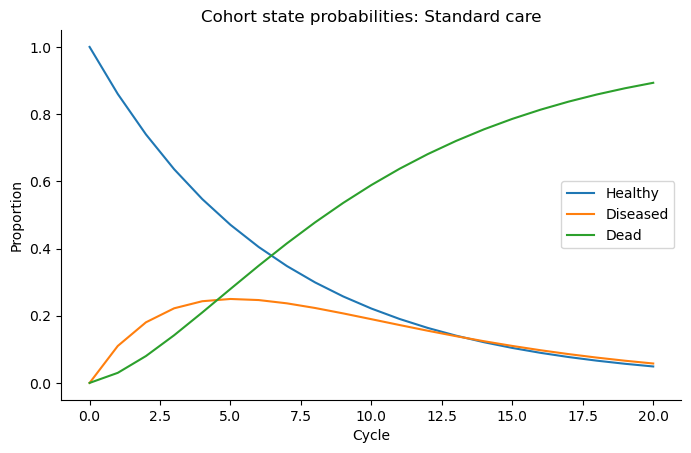

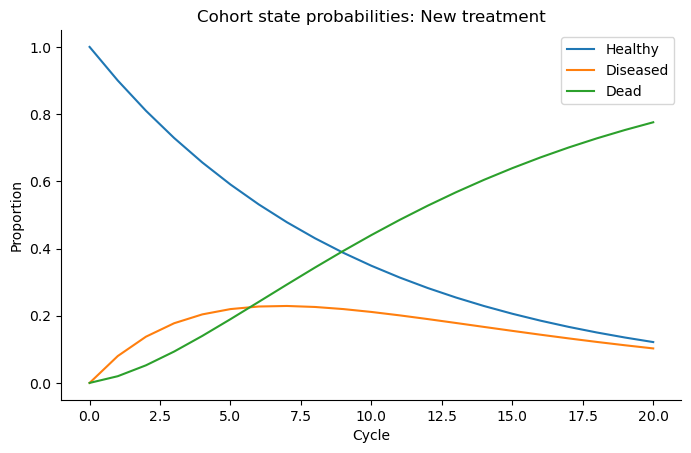

In [6]:
def plot_cohort_trajectories(cohort, title):
    fig, ax = plt.subplots()
    for j, name in enumerate(state_names):
        ax.plot(np.arange(cohort.shape[0]), cohort[:, j], label=name)
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Proportion")
    ax.set_title(title)
    ax.legend()
    plt.show()

plot_cohort_trajectories(cohort_standard, "Cohort state probabilities: Standard care")
plot_cohort_trajectories(cohort_new, "Cohort state probabilities: New treatment")


### Expected discounted costs and QALYs from the cohort model

At each cycle, expected values are obtained by weighting state-specific costs/utilities by the cohort distribution.

For treatment-specific drug costs, we add the acquisition cost only for living states.


In [7]:
alive = np.array([1, 1, 0], dtype=float)

def cohort_cost_qaly(cohort, state_costs, state_utils, drug_cost_alive, w_cost, w_qaly, cycle_length=1.0):
    # Use states at the start of each cycle for reward accumulation
    d = cohort[:-1]
    per_cycle_cost = d @ state_costs + drug_cost_alive * (d @ alive)
    per_cycle_qaly = d @ state_utils * cycle_length

    total_cost = np.sum(w_cost * per_cycle_cost)
    total_qaly = np.sum(w_qaly * per_cycle_qaly)

    return total_cost, total_qaly, per_cycle_cost, per_cycle_qaly

# cost & QALY for standard care
cost_std, qaly_std, c_std_cycle, q_std_cycle = cohort_cost_qaly(
    cohort_standard, state_costs, state_utils, drug_cost_standard, w_cost, w_qaly, cycle_length
)
# cost & QALY for new treatment
cost_new, qaly_new, c_new_cycle, q_new_cycle = cohort_cost_qaly(
    cohort_new, state_costs, state_utils, drug_cost_new, w_cost, w_qaly, cycle_length
)

# compute ICER
icer = (cost_new - cost_std) / (qaly_new - qaly_std)

summary = pd.DataFrame({
    "strategy": ["Standard care", "New treatment"],
    "discounted_cost": [cost_std, cost_new],
    "discounted_qalys": [qaly_std, qaly_new],
})
summary


,strategy,discounted_cost,discounted_qalys
0,Standard care,21896.084975,7.199961
1,New treatment,43727.646494,8.668840


In [8]:
incremental = pd.DataFrame({
    "comparison": ["New vs Standard"],
    "incremental_cost": [cost_new - cost_std],
    "incremental_qalys": [qaly_new - qaly_std],
    "ICER": [icer],
})
incremental


,comparison,incremental_cost,incremental_qalys,ICER
0,New vs Standard,21831.561519,1.468879,14862.736999


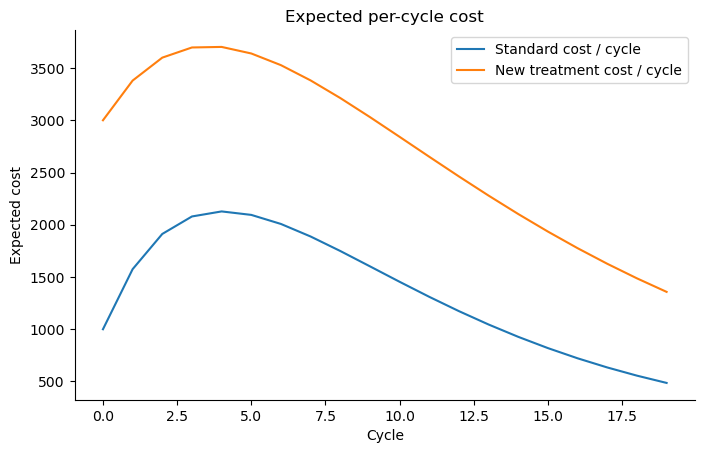

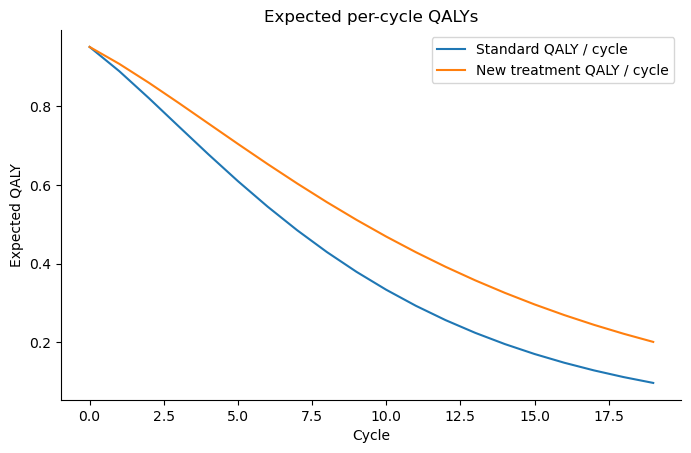

In [9]:
fig, ax = plt.subplots()
ax.plot(np.arange(n_cycles), c_std_cycle, label="Standard cost / cycle")
ax.plot(np.arange(n_cycles), c_new_cycle, label="New treatment cost / cycle")
ax.set_xlabel("Cycle")
ax.set_ylabel("Expected cost")
ax.set_title("Expected per-cycle cost")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.plot(np.arange(n_cycles), q_std_cycle, label="Standard QALY / cycle")
ax.plot(np.arange(n_cycles), q_new_cycle, label="New treatment QALY / cycle")
ax.set_xlabel("Cycle")
ax.set_ylabel("Expected QALY")
ax.set_title("Expected per-cycle QALYs")
ax.legend()
plt.show()


### Individual-level Monte Carlo microsimulation

Instead of propagating the whole cohort distribution analytically, we can simulate many individual patient trajectories.


In [10]:
# define utility functions first

def sample_next_state(current_state, P, rng):
    return rng.choice(np.arange(P.shape[1]), p=P[current_state])

def simulate_patient(P, initial_state, n_cycles, rng):
    states = np.zeros(n_cycles + 1, dtype=int)
    states[0] = initial_state
    for t in range(n_cycles):
        states[t + 1] = sample_next_state(states[t], P, rng)
    return states

def evaluate_patient(states, state_costs, state_utils, drug_cost_alive, w_cost, w_qaly):
    total_cost = 0.0
    total_qaly = 0.0
    for t, s in enumerate(states[:-1]):
        total_cost += w_cost[t] * (state_costs[s] + drug_cost_alive * (s != 2))
        total_qaly += w_qaly[t] * state_utils[s]
    return total_cost, total_qaly

def microsim(P, n_patients, initial_state, n_cycles, state_costs, state_utils, drug_cost_alive, w_cost, w_qaly, seed=1):
    rng_local = np.random.default_rng(seed)
    costs = np.zeros(n_patients)
    qalys = np.zeros(n_patients)
    state_counts = np.zeros((n_cycles + 1, P.shape[0]), dtype=int)

    for i in range(n_patients):
        states = simulate_patient(P, initial_state, n_cycles, rng_local)
        c, q = evaluate_patient(states, state_costs, state_utils, drug_cost_alive, w_cost, w_qaly)
        costs[i] = c
        qalys[i] = q
        for t, s in enumerate(states):
            state_counts[t, s] += 1

    return costs, qalys, state_counts / n_patients

In [11]:
# then simulate for 5,000 patients under each treatment 

mc_cost_std, mc_qaly_std, mc_cohort_std = microsim(
    P_standard, 5000, 0, n_cycles, state_costs, state_utils, drug_cost_standard, w_cost, w_qaly, seed=101
)
mc_cost_new, mc_qaly_new, mc_cohort_new = microsim(
    P_new, 5000, 0, n_cycles, state_costs, state_utils, drug_cost_new, w_cost, w_qaly, seed=202
)


In [12]:
# summarize the two cohorts
mc_summary = pd.DataFrame({
    "strategy": ["Standard care", "New treatment"],
    "mean_cost": [mc_cost_std.mean(), mc_cost_new.mean()],
    "mean_qalys": [mc_qaly_std.mean(), mc_qaly_new.mean()],
    "sd_cost": [mc_cost_std.std(ddof=1), mc_cost_new.std(ddof=1)],
    "sd_qalys": [mc_qaly_std.std(ddof=1), mc_qaly_new.std(ddof=1)],
})
mc_summary


,strategy,mean_cost,mean_qalys,sd_cost,sd_qalys
0,Standard care,22327.411007,7.260988,16831.238252,3.88040
1,New treatment,43713.658108,8.621448,23016.854876,4.15157


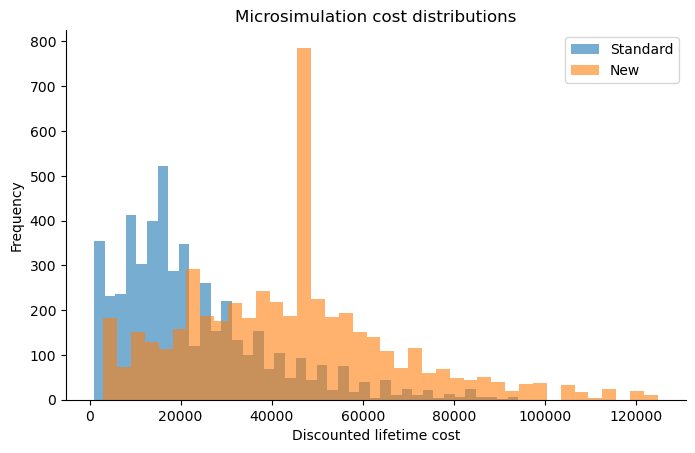

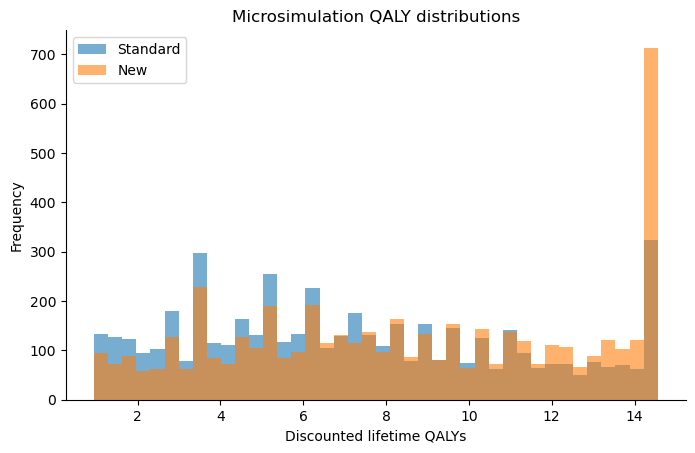

In [13]:
# plot simulated cohorts

fig, ax = plt.subplots()
ax.hist(mc_cost_std, bins=40, alpha=0.6, label="Standard")
ax.hist(mc_cost_new, bins=40, alpha=0.6, label="New")
ax.set_xlabel("Discounted lifetime cost")
ax.set_ylabel("Frequency")
ax.set_title("Microsimulation cost distributions")
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.hist(mc_qaly_std, bins=40, alpha=0.6, label="Standard")
ax.hist(mc_qaly_new, bins=40, alpha=0.6, label="New")
ax.set_xlabel("Discounted lifetime QALYs")
ax.set_ylabel("Frequency")
ax.set_title("Microsimulation QALY distributions")
ax.legend()
plt.show()


### Comparing cohort and microsimulation outputs

The cohort model gives the exact expected proportions under the Markov model.  
The microsimulation estimates these quantities by repeated random sampling.

We would expect the microsimulations, on average, be similar to the cohort/population-level results. (Otherwise there's a bug in your code!)


In [14]:
comparison_df = pd.DataFrame({
    "cycle": np.arange(n_cycles + 1),
    "cohort_dead_standard": cohort_standard[:, 2],
    "mc_dead_standard": mc_cohort_std[:, 2],
    "cohort_dead_new": cohort_new[:, 2],
    "mc_dead_new": mc_cohort_new[:, 2],
})
comparison_df.head(10)


,cycle,cohort_dead_standard,mc_dead_standard,cohort_dead_new,mc_dead_new
0,0,0.000000,0.0000,0.000000,0.0000
1,1,0.030000,0.0266,0.020000,0.0190
2,2,0.080000,0.0766,0.052400,0.0512
3,3,0.141876,0.1354,0.093368,0.0896
4,4,0.209813,0.2048,0.139922,0.1394
5,5,0.279722,0.2666,0.189760,0.1910
6,6,0.348802,0.3364,0.241125,0.2434
7,7,0.415198,0.4050,0.292692,0.2964
8,8,0.477748,0.4640,0.343480,0.3440
9,9,0.535792,0.5248,0.392779,0.3900


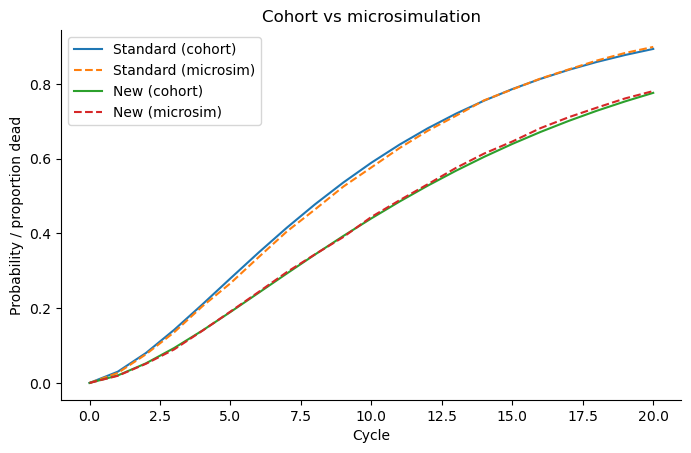

In [15]:
fig, ax = plt.subplots()
ax.plot(comparison_df["cycle"], comparison_df["cohort_dead_standard"], label="Standard (cohort)")
ax.plot(comparison_df["cycle"], comparison_df["mc_dead_standard"], linestyle="--", label="Standard (microsim)")
ax.plot(comparison_df["cycle"], comparison_df["cohort_dead_new"], label="New (cohort)")
ax.plot(comparison_df["cycle"], comparison_df["mc_dead_new"], linestyle="--", label="New (microsim)")
ax.set_xlabel("Cycle")
ax.set_ylabel("Probability / proportion dead")
ax.set_title("Cohort vs microsimulation")
ax.legend()
plt.show()


## Part II. A simple Q-learning treatment policy


We define a tiny MDP motivated by treatment choice:

- patient health status has three levels:  
  **0 = good**, **1 = moderate**, **2 = severe**
- action has two choices:  
  **0 = conservative treatment**, **1 = aggressive treatment**

Aggressive treatment may improve future health more, but it also has higher immediate toxicity/cost.


In [16]:
health_states = ["Good", "Moderate", "Severe"]
action_names = ["Conservative", "Aggressive"]

n_health = 3 # 3 health states
n_actions = 2 # 2 actions 

# Transition probabilities P[a, s, s']
P_mdp = np.zeros((n_actions, n_health, n_health))

# Conservative treatment
P_mdp[0] = np.array([
    [0.80, 0.18, 0.02],  # Good
    [0.20, 0.60, 0.20],  # Moderate
    [0.05, 0.30, 0.65],  # Severe
])

# Aggressive treatment
P_mdp[1] = np.array([
    [0.72, 0.25, 0.03],  # Good: slightly more toxicity risk
    [0.35, 0.50, 0.15],  # Moderate: better chance to improve
    [0.12, 0.48, 0.40],  # Severe: much better chance to improve
])

# Base utility by state, action penalty, and terminal-like horizon penalty can all be encoded in reward
state_reward = np.array([2.0, 1.0, -1.0])        # better health gives higher reward
action_penalty = np.array([0.0, 0.6])            # aggressive treatment has toxicity/cost penalty

gamma = 0.95 # discount factor 

for a in range(n_actions):
    assert np.allclose(P_mdp[a].sum(axis=1), 1)


### Reward function

We use a simple one-step reward:

$$
r_t = \text{health value}(s_t) - \text{treatment penalty}(a_t).
$$

This is not meant to be clinically realistic. Just as a compact example to make things easier. 


In [17]:
def reward_fn(state, action):
    return state_reward[state] - action_penalty[action]

# Quick reward table
reward_table = pd.DataFrame(
    [[reward_fn(s, a) for a in range(n_actions)] for s in range(n_health)],
    index=health_states,
    columns=action_names
)
reward_table


,Conservative,Aggressive
Good,2.0,1.4
Moderate,1.0,0.4
Severe,-1.0,-1.6


In [18]:
def step_env(state, action, rng):
    reward = reward_fn(state, action)
    next_state = rng.choice(np.arange(n_health), p=P_mdp[action, state])
    return next_state, reward

def run_policy(policy, start_state=2, n_steps=15, seed=0):
    rng_local = np.random.default_rng(seed)
    state = start_state
    states = [state]
    rewards = []
    actions = []
    for _ in range(n_steps):
        action = policy[state]
        next_state, reward = step_env(state, action, rng_local)
        actions.append(action)
        rewards.append(reward)
        states.append(next_state)
        state = next_state
    return np.array(states), np.array(actions), np.array(rewards)


### Q-learning

For a finite state-action space, Q-learning updates

$$
Q(s,a) \leftarrow Q(s,a) + \alpha \left[
r + \gamma \max_{a'} Q(s',a') - Q(s,a)
\right].
$$

We use an $\varepsilon$-greedy exploration rule. 

That is, in each step, with probabilty $1-\varepsilon$ we use
the current best action ("exploitation"), and with probability $\varepsilon$ we take a random action (exploration). 


In [19]:
def q_learning(
    P_mdp,
    reward_fn,
    n_episodes=4000,
    max_steps=20,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.15,
    epsilon_decay=0.999,
    epsilon_min=0.02,
    seed=123,
):
    """
    Q-learning algorithm for learning an optimal treatment policy in an MDP.

    Parameters
    ----------
    P_mdp : ndarray (n_actions, n_states, n_states)
        Transition probability array.
        P_mdp[a, s, s'] = P(s_{t+1}=s' | s_t=s, a_t=a)

    reward_fn : function
        Function that returns the immediate reward for taking action a in state s:
        reward = reward_fn(state, action)

    n_episodes : int
        Number of simulated episodes used to learn the policy.

    max_steps : int
        Maximum number of decision steps within each episode.

    alpha : float
        Learning rate for Q-learning updates.
        Controls how much new information replaces old estimates.

    gamma : float
        Discount factor for future rewards.
        Values close to 1 emphasize long-term rewards.

    epsilon : float
        Initial exploration probability for epsilon-greedy action selection.

    epsilon_decay : float
        Multiplicative factor controlling how exploration decreases over time.

    epsilon_min : float
        Minimum exploration probability.

    seed : int
        Random seed for reproducibility.

    Returns
    -------
    Q : ndarray (n_states, n_actions)
        Learned Q-values representing expected cumulative reward.

    episode_returns : ndarray
        Total discounted reward obtained in each episode.
    """

    # Random number generator for reproducibility
    rng_local = np.random.default_rng(seed)

    # Extract dimensions from the transition tensor
    n_actions, n_states, _ = P_mdp.shape

    # Initialize Q-table with zeros
    # Q[s, a] = expected long-term reward from state s taking action a
    Q = np.zeros((n_states, n_actions))

    # Track total return obtained in each episode
    episode_returns = []

    # Loop over training episodes
    for ep in range(n_episodes):

        # Start episode from a random state
        state = rng_local.integers(0, n_states)

        total_return = 0.0
        discount = 1.0   # keeps track of gamma^t

        # Simulate sequential decisions within an episode
        for _ in range(max_steps):

            # Epsilon-greedy action selection
            # With probability epsilon: explore random action
            # Otherwise: exploit best current action
            if rng_local.random() < epsilon:
                action = rng_local.integers(0, n_actions)
            else:
                action = int(np.argmax(Q[state]))

            # Obtain immediate reward for the chosen action
            reward = reward_fn(state, action)

            # Sample next state from transition probabilities
            # P_mdp[action, state] gives probability distribution over next states
            next_state = rng_local.choice(
                np.arange(n_states),
                p=P_mdp[action, state]
            )

            # Q-learning temporal difference (TD) target
            # reward + discounted estimate of optimal future value
            td_target = reward + gamma * np.max(Q[next_state])

            # TD error measures difference between prediction and target
            td_error = td_target - Q[state, action]

            # Update Q-value
            Q[state, action] += alpha * td_error

            # Accumulate discounted return for this episode
            total_return += discount * reward

            # Update discount multiplier
            discount *= gamma

            # Move to next state
            state = next_state

        # Store total return from this episode
        episode_returns.append(total_return)

        # Gradually reduce exploration over time
        epsilon = max(epsilon * epsilon_decay, epsilon_min)

    return Q, np.array(episode_returns)


# Train the Q-learning algorithm
Q, episode_returns = q_learning(P_mdp, reward_fn, seed=999)

Q

array([[24.55458424, 22.46613028],
       [21.51527144, 19.09941111],
       [14.80619181, 17.68868481]])

In [21]:
# learn the best policy based on learned Q function
learned_policy = np.argmax(Q, axis=1)

# show the policy
policy_df = pd.DataFrame({
    "state": health_states,
    "best_action_index": learned_policy,
    "best_action": [action_names[a] for a in learned_policy],
})
policy_df


,state,best_action_index,best_action
0,Good,0,Conservative
1,Moderate,0,Conservative
2,Severe,1,Aggressive


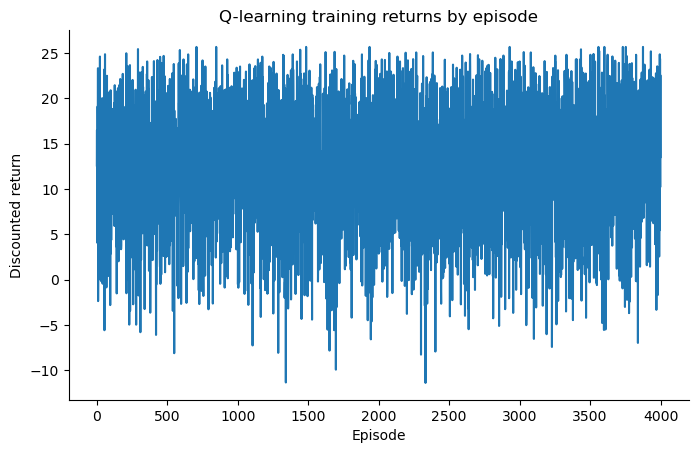

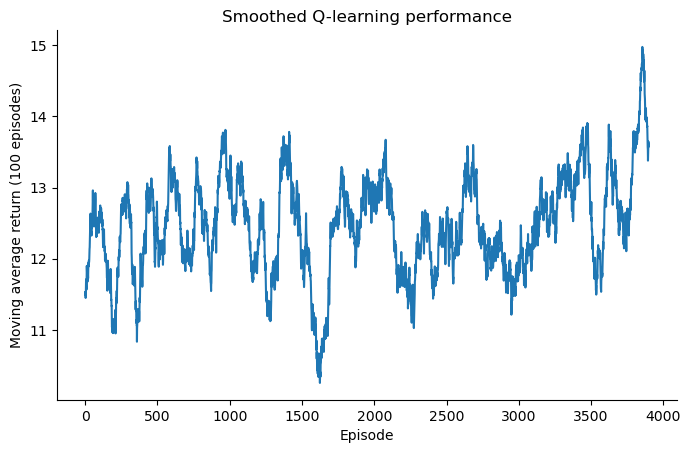

In [22]:
# plot results

fig, ax = plt.subplots()
ax.plot(episode_returns)
ax.set_xlabel("Episode")
ax.set_ylabel("Discounted return")
ax.set_title("Q-learning training returns by episode")
plt.show()

window = 100
smoothed = np.convolve(episode_returns, np.ones(window)/window, mode="valid")
fig, ax = plt.subplots()
ax.plot(smoothed)
ax.set_xlabel("Episode")
ax.set_ylabel(f"Moving average return ({window} episodes)")
ax.set_title("Smoothed Q-learning performance")
plt.show()


### Interpreting the learned policy

We can compare the learned policy to two simple fixed policies:

- always use **conservative**
- always use **aggressive**
- use the **learned Q-learning policy**


In [23]:
always_conservative = np.zeros(n_health, dtype=int)
always_aggressive = np.ones(n_health, dtype=int)

def evaluate_policy(policy, n_episodes=2000, max_steps=20, gamma=0.95, seed=321):
    rng_local = np.random.default_rng(seed)
    returns = np.zeros(n_episodes)

    for ep in range(n_episodes):
        state = rng_local.integers(0, n_health)
        total_return = 0.0
        discount = 1.0
        for _ in range(max_steps):
            action = policy[state]
            reward = reward_fn(state, action)
            next_state = rng_local.choice(np.arange(n_health), p=P_mdp[action, state])
            total_return += discount * reward
            discount *= gamma
            state = next_state
        returns[ep] = total_return
    return returns

ret_cons = evaluate_policy(always_conservative, seed=101)
ret_aggr = evaluate_policy(always_aggressive, seed=202)
ret_learned = evaluate_policy(learned_policy, seed=303)

policy_compare = pd.DataFrame({
    "policy": ["Always conservative", "Always aggressive", "Learned Q-policy"],
    "mean_discounted_return": [ret_cons.mean(), ret_aggr.mean(), ret_learned.mean()],
    "sd_discounted_return": [ret_cons.std(ddof=1), ret_aggr.std(ddof=1), ret_learned.std(ddof=1)],
})
policy_compare


,policy,mean_discounted_return,sd_discounted_return
0,Always conservative,11.609289,7.534877
1,Always aggressive,7.549964,4.858113
2,Learned Q-policy,13.031491,6.492416


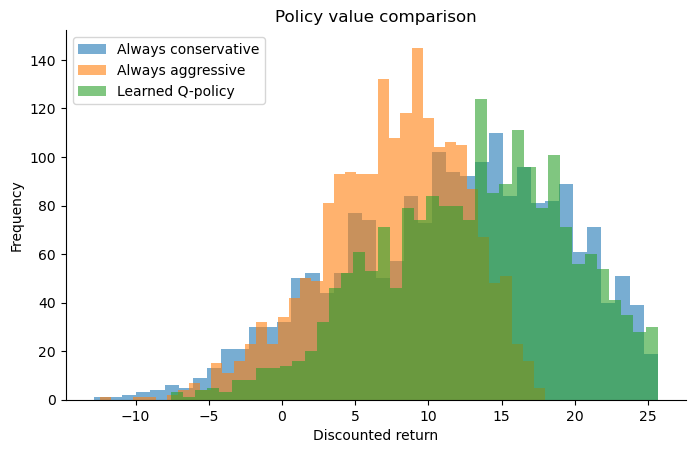

In [24]:
fig, ax = plt.subplots()
ax.hist(ret_cons, bins=40, alpha=0.6, label="Always conservative")
ax.hist(ret_aggr, bins=40, alpha=0.6, label="Always aggressive")
ax.hist(ret_learned, bins=40, alpha=0.6, label="Learned Q-policy")
ax.set_xlabel("Discounted return")
ax.set_ylabel("Frequency")
ax.set_title("Policy value comparison")
ax.legend()
plt.show()


In [26]:
# show an example trajectory with learned policy

example_states, example_actions, example_rewards = run_policy(learned_policy, start_state=2, n_steps=12, seed=77)

trajectory_df = pd.DataFrame({
    "time": np.arange(len(example_actions)),
    "state_t": [health_states[s] for s in example_states[:-1]],
    "action_t": [action_names[a] for a in example_actions],
    "reward_t": example_rewards,
    "state_t_plus_1": [health_states[s] for s in example_states[1:]],
})
trajectory_df


,time,state_t,action_t,reward_t,state_t_plus_1
0,0,Severe,Aggressive,-1.6,Severe
1,1,Severe,Aggressive,-1.6,Moderate
2,2,Moderate,Conservative,1.0,Moderate
3,3,Moderate,Conservative,1.0,Moderate
4,4,Moderate,Conservative,1.0,Moderate
5,5,Moderate,Conservative,1.0,Moderate
6,6,Moderate,Conservative,1.0,Severe
7,7,Severe,Aggressive,-1.6,Good
8,8,Good,Conservative,2.0,Good
9,9,Good,Conservative,2.0,Good
